# Gaussian Process Regression

When we say 'Regression' in machine learning, we practically just mean "predicting based on data".

It can start with simple examples, such as plotting height v weight on a two-dimensional axis, and drawing a line of best fit across your data such that you can predict the height of someone new based solely on their known weight.

Gaussian Process, on the other hand, is a prediction method that utilises several lines of best fits to make its most accurate prediction. For every one point that is to be predicted based on the lines of best fits from existing data, the Gaussian Process calculates both a mean and a standard deviation.

In this context, the mean represents the best guess for the prediction, whereas the standard deviation represents the confidence level of the model for its prediction.

Combining the two, we reach **Gaussian Process Regression**, a method that entails first predicting the curves based on existing data, and then calculating the confidence level of the prediction at each point.

For this coding tutorial, we will utilise **scikit-learn** for its simplicity and broad scale applicability.

In [ ]:
import numpy as np # Import NumPy for handling numbers and arrays
import matplotlib.pyplot as plt # Import Matplotlib for creating plots and visualising data
from sklearn.gaussian_process import GaussianProcessRegressor # Import the main GPR model from scikit-learn
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C # Import two key kernel components
# RBF (Radial Basis Function) defines how predictions change with distance
# ConstantKernel sets the overall scale of variation


# Creating Input Data X and Observations y (with Noise)


In [ ]:
X = np.linspace(-5, 5, 10).reshape(-1, 1)      # 10 points between -5 and 5
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # sin(x) + noise

# Choosing a Kernel (Covariance Function)

In [ ]:
# C - ConstantKernel: set the overall scale
# RBF - Radial Basis Function: controls how quickly predictions change

kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# C(1.0, A) means a starting scale of 1.0, whereas C(B, (1e-3, 1e3)) just means the variations are between 0.001 and 1000

# Training the Model

In [ ]:
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.2**2)
# n_restarts_optimizer helps us find stronger kernel settings by trying multiple starting points
# alpha = 0.2**2 tells the model how much noise to expect


gpr.fit(X, y) #plot the data
print("Learned kernel:", gpr.kernel_) #calculated kernel


Learned kernel: 0.895**2 * RBF(length_scale=1.62)


# Visualization

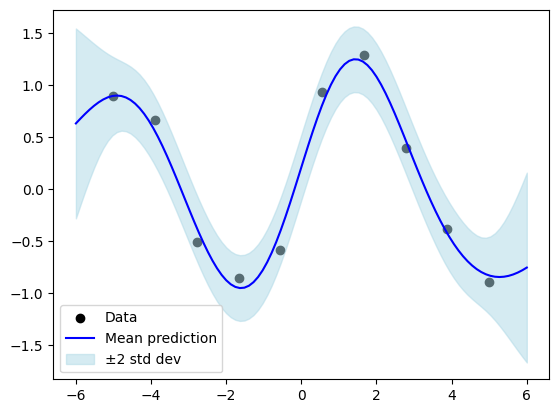

In [ ]:
X_test = np.linspace(-6, 6, 100).reshape(-1, 1)
# Create 100 evenly spaced points between -6 and 6 as test input data
# These are the x-values where we want to make predictions

y_mean, y_std = gpr.predict(X_test, return_std=True)
# Use the trained Gaussian Process model to predict at each X_test point
# y_mean contains the predicted values (the model’s best guess)
# y_std contains the uncertainty (standard deviation) around each prediction

plt.figure()
plt.scatter(X, y, color='black', label='Data')
#plotting data points
plt.plot(X_test, y_mean, 'blue', label='Mean prediction')
#plotting prediction points
plt.fill_between(X_test.ravel(), y_mean - 2*y_std, y_mean + 2*y_std,
                 color='lightblue', alpha=0.5, label='±2 std dev')
#plotting certainty of model (wider = more uncertain)
plt.legend()
plt.show()

# What Is Going On?
Important to keep in mind:
Gaussian Process Regression is highlighting that one exact line of best fit is not exactly the ideal method to make a prediction.

The fundamental benefit of Gaussian Progress Regression is the ability to highlight the confidence in the model at certain points, depicted by a smaller envelope encasing our main prediction curve.

The kernel is responsible for the smoothness of a prediction model. It determines how similar the prediction is for two outputs given the similarities of their inputs.